## Weight Decay

c:\Users\babie\OneDrive\바탕 화면
c:\Users\babie\OneDrive
epoch:0, train acc:0.06666666666666667, test acc:0.068
epoch:1, train acc:0.10666666666666667, test acc:0.0878
epoch:2, train acc:0.14666666666666667, test acc:0.1182
epoch:3, train acc:0.17666666666666667, test acc:0.1429
epoch:4, train acc:0.23333333333333334, test acc:0.1673
epoch:5, train acc:0.24333333333333335, test acc:0.178
epoch:6, train acc:0.2833333333333333, test acc:0.1991
epoch:7, train acc:0.29333333333333333, test acc:0.2089
epoch:8, train acc:0.29333333333333333, test acc:0.2104
epoch:9, train acc:0.30666666666666664, test acc:0.2302
epoch:10, train acc:0.33666666666666667, test acc:0.2536
epoch:11, train acc:0.37333333333333335, test acc:0.2761
epoch:12, train acc:0.43, test acc:0.2914
epoch:13, train acc:0.4633333333333333, test acc:0.3155
epoch:14, train acc:0.4866666666666667, test acc:0.3244
epoch:15, train acc:0.48333333333333334, test acc:0.3316
epoch:16, train acc:0.53, test acc:0.3603
epoch:17, train acc:0.

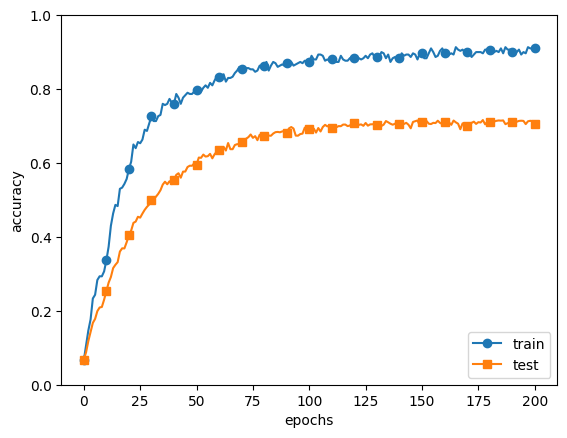

In [3]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1  # 현실과 괴리가 생기지 않도록 함 / train과 test의 차이가 거의 없게 함
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100,100,100,100,100,100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        
        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


## DropOut

c:\
c:\
train loss:2.325049604351952
=== epoch:1, train acc:0.08666666666666667, test acc:0.078 ===
train loss:2.2938416966842077
train loss:2.297821384811331
train loss:2.2981514008613515
=== epoch:2, train acc:0.1, test acc:0.0844 ===
train loss:2.294590587731506
train loss:2.2925250457062343
train loss:2.2933133658979172
=== epoch:3, train acc:0.11, test acc:0.0886 ===
train loss:2.2858745937486726
train loss:2.295942934375631
train loss:2.301030831129931
=== epoch:4, train acc:0.12, test acc:0.0943 ===
train loss:2.2792114437174558
train loss:2.2837556041398015
train loss:2.2949997480492845
=== epoch:5, train acc:0.14, test acc:0.1005 ===
train loss:2.3038180103341968
train loss:2.283014189394812
train loss:2.2816332137856903
=== epoch:6, train acc:0.14333333333333334, test acc:0.1082 ===
train loss:2.2657443057099216
train loss:2.276907278426801
train loss:2.2653917693195327
=== epoch:7, train acc:0.16, test acc:0.1175 ===
train loss:2.2696586900218194
train loss:2.261159027525505

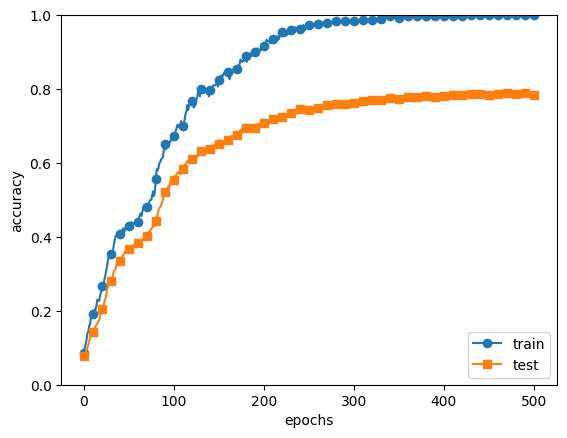

In [10]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

dropout_ratio = 0.1  
use_dropout = True
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100,100,100,100,100,100], output_size=10,
                        use_dropout = use_dropout, dropout_ration = dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test, 
                  epochs=301, mini_batch_size=100, 
                  optimizer='sgd', optimizer_param={'lr':0.01}, verbose=True)
trainer.train()
train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        
        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()
